# FEBAM 기반 LoRa 스펙트로그램 디노이징

## FEBAM (Feature-Extracting BAM)
- **확장 → 압축 → 확장** 구조
- 일반 AE와 반대: 먼저 확장해서 특징 추출, 그 다음 bottleneck으로 압축

## 프로세스 흐름 (ISTFT 없음!)

```
┌─────────────────────────────────────────────────────────────────────┐
│                        데이터 생성 (generate.ipynb)                   │
├─────────────────────────────────────────────────────────────────────┤
│  LoRa(SF=9, BW=125kHz, OSF=8)                                       │
│       ↓                                                              │
│  gen_symbol_fs(sym) → 클린 IQ (4096 샘플/심볼)                        │
│       ↓                                                              │
│  저장: dataset_sf9_bw125k/clean_iq/sym_XXX_iq.npy                   │
└─────────────────────────────────────────────────────────────────────┘
                              ↓
┌─────────────────────────────────────────────────────────────────────┐
│                        학습 (training_basic.ipynb)                   │
├─────────────────────────────────────────────────────────────────────┤
│  1. 클린 IQ 로드                                                     │
│       ↓                                                              │
│  2. STFT → BW 범위만 crop (±62.5kHz)                                │
│       ↓                                                              │
│  3. Magnitude (dB) → Flatten → 2048 패딩                            │
│       ↓                                                              │
│  4. Z-score 정규화                                                   │
│       ↓                                                              │
│  5. FEBAM (확장→압축→확장): 2048 → 4096 → 64 → 4096 → 2048          │
└─────────────────────────────────────────────────────────────────────┘
                              ↓
┌─────────────────────────────────────────────────────────────────────┐
│                        디노이징 & 평가 (ISTFT 없음!)                  │
├─────────────────────────────────────────────────────────────────────┤
│  Noisy IQ → STFT(BW crop) → Magnitude(dB) → FEBAM 디노이징           │
│       ↓                                                              │
│  스펙트로그램에서 직접 심볼 추정 (피크 주파수 추적)                     │
│       ↓                                                              │
│  평가: Accuracy, F0.5, F1.0, F2.0, F3.0                              │
└─────────────────────────────────────────────────────────────────────┘
```

## 파라미터 설정
| 파라미터 | 값 | 설명 |
|---------|-----|------|
| SF | 9 | Spreading Factor |
| BW | 125 kHz | 대역폭 |
| OSF | 8 | Oversampling Factor |
| FS | 1 MHz | 샘플링 주파수 (BW × OSF) |
| 심볼 수 | 512 | 2^SF |
| 입력 차원 | **2048** | BW crop 후 (vs 기존 16384) |

## FEBAM vs 일반 BAM
| 구조 | 레이어 흐름 | 특징 |
|------|-------------|------|
| 일반 BAM | n → k → n | 단순 압축 → 확장 |
| **FEBAM** | n → m(확장) → k → m → n | 특징 추출 후 압축 |

In [1]:
import os, glob, math, sys, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils.LoRa import LoRa, MultiBAM

# ⭐ 기존 잘 작동하는 estimate_symbol_custom 사용
import importlib
import utils.my_lora_utils
importlib.reload(utils.my_lora_utils)
from utils.my_lora_utils import estimate_symbol_custom

np.random.seed(42)

# ===== LoRa 파라미터 =====
SF = 9
BW = 125_000           # 125kHz
OSF = 8                # Oversampling factor
FS = 1_000_000         # 1MHz (= BW * OSF)

# STFT 파라미터
N_sym = (2**SF) * OSF  # 심볼당 샘플 수 = 4096
STFT_PARAMS = {
    'nperseg': 256,
    'noverlap': 128,
    'nfft': 512,
    'window': 'hann'
}

# 학습 파라미터
SNR_MIN = -10
SNR_MAX = 0
TRAIN_BATCH = 64
TRAIN_MAX_STEPS = 3000
EARLY_PATIENCE = 100
EARLY_TOL = 1e-6

# ===== FEBAM: 2^i 기반 구조 =====
# bottleneck 크기 = 2^BOTTLENECK_I
BOTTLENECK_I = 6  # 2^6 = 64

# 데이터 경로
DATA_DIR = "dataset_sf9_bw125k/clean_iq"

print(f"LoRa 설정: SF={SF}, BW={BW/1000:.0f}kHz, OSF={OSF}, FS={FS/1e6:.1f}MHz")
print(f"심볼당 샘플 수: {N_sym} (= 2^{SF} × {OSF})")
print(f"FEBAM bottleneck: 2^{BOTTLENECK_I} = {2**BOTTLENECK_I}")

LoRa 설정: SF=9, BW=125kHz, OSF=8, FS=1.0MHz
심볼당 샘플 수: 4096 (= 2^9 × 8)
FEBAM bottleneck: 2^6 = 64


In [2]:
# ===== 스펙트로그램 처리 함수 (BW Crop 버전) =====

def stft_bw_crop(iq, fs=FS, bw=BW, params=STFT_PARAMS):
    """
    STFT 후 BW 범위만 crop하여 반환
    - 전체: 512 freq bins → crop 후: ~64 freq bins
    - 입력 차원 8배 감소!
    """
    f, t, Z = stft(iq, fs=fs, window=params['window'], nperseg=params['nperseg'],
                   noverlap=params['noverlap'], nfft=params['nfft'],
                   boundary=None, padded=False, return_onesided=False)
    
    # FFT shift (DC를 중앙으로)
    f_shift = np.fft.fftshift(f)
    Z_shift = np.fft.fftshift(Z, axes=0)
    
    # BW 범위만 crop (±BW/2)
    mask = (f_shift >= -bw/2) & (f_shift < bw/2)
    f_crop = f_shift[mask]
    Z_crop = Z_shift[mask, :]
    
    # Magnitude (dB)
    mag = np.abs(Z_crop)
    mag_db = 20 * np.log10(mag + 1e-10)
    
    return mag_db, f_crop, {'shape': mag_db.shape, 'f_crop': f_crop, 'mask': mask}

def flatten_spec(spec_2d):
    """2D → 1D flatten + power-of-2 패딩"""
    vec = spec_2d.flatten()
    L = len(vec)
    pow2 = 1 << math.ceil(math.log2(max(L, 1)))
    pad_len = pow2 - L
    if pad_len > 0:
        vec = np.pad(vec, (0, pad_len))
    return vec, {'orig_len': L, 'pad_len': pad_len, 'shape': spec_2d.shape}

def unflatten_spec(vec, meta):
    """1D → 2D 복원"""
    return vec[:meta['orig_len']].reshape(meta['shape'])

def zscore(x, mean, std):
    return (x - mean) / (std + 1e-8)

def zscore_inv(xn, mean, std):
    return xn * (std + 1e-8) + mean

# 테스트: BW crop 효과 확인
print("="*60)
print("BW Crop 효과:")
test_iq = np.random.randn(N_sym) + 1j * np.random.randn(N_sym)
mag_crop, f_crop, meta = stft_bw_crop(test_iq)
print(f"  BW crop 스펙트로그램: {mag_crop.shape} (freq={mag_crop.shape[0]}, time={mag_crop.shape[1]})")
flat_test, pad_meta = flatten_spec(mag_crop)
print(f"  Flatten: {pad_meta['orig_len']} → 패딩 후: {len(flat_test)} (2^{int(math.log2(len(flat_test)))})")
print(f"  ✅ 기존 16384 → 현재 {len(flat_test)} (약 {16384//len(flat_test)}배 축소!)")
print("="*60)

BW Crop 효과:
  BW crop 스펙트로그램: (64, 31) (freq=64, time=31)
  Flatten: 1984 → 패딩 후: 2048 (2^11)
  ✅ 기존 16384 → 현재 2048 (약 8배 축소!)


In [ ]:
# ===== FEBAM Recall & 심볼 추정 =====

def febam_recall(model, noisy_input):
    """FEBAM의 recall: 노이즈 입력 → 학습된 클린 패턴으로 복원"""
    compressed = model.compress(noisy_input)
    recalled = model.decompress(compressed)
    return recalled

def denoise_spectrogram(noisy_iq, model, global_mean, global_std):
    """노이즈 IQ → BW crop 스펙트로그램 → FEBAM recall → 디노이징된 스펙트로그램"""
    mag_noisy, f_crop, meta = stft_bw_crop(noisy_iq)
    flat_noisy, pad_meta = flatten_spec(mag_noisy)
    flat_norm = zscore(flat_noisy, global_mean, global_std)
    
    # FEBAM Recall
    flat_recalled = febam_recall(model, flat_norm.reshape(1, -1)).flatten()
    flat_denorm = zscore_inv(flat_recalled, global_mean, global_std)
    
    mag_recalled = unflatten_spec(flat_denorm, pad_meta)
    return mag_recalled, mag_noisy, f_crop

def unit_power(x):
    """신호를 단위 파워로 정규화"""
    p = np.mean(np.abs(x)**2)
    return x / np.sqrt(p) if p > 1e-12 else x

# ===== 스펙트로그램에서 직접 심볼 추정 =====
def estimate_from_spectrogram(mag_db, f_crop, sf=SF, bw=BW):
    """
    스펙트로그램에서 직접 심볼 추정 (ISTFT 없이!)
    
    LoRa chirp 특성:
    - 심볼 값에 따라 chirp의 시작 주파수가 결정됨
    - 시작 주파수 f_start = -BW/2 + (symbol / 2^SF) * BW
    - 스펙트로그램에서 첫 번째 time frame의 피크 주파수로 추정
    
    Args:
        mag_db: 스펙트로그램 (dB), shape (n_freq, n_time)
        f_crop: 주파수 축 (Hz)
        sf: Spreading Factor
        bw: Bandwidth (Hz)
    
    Returns:
        estimated_symbol: 추정된 심볼 값 (0 ~ 2^SF - 1)
        confidence: 피크의 상대적 강도 (dB)
    """
    n_symbols = 2 ** sf
    
    # 방법 1: 첫 몇 개 time frame의 피크 주파수 평균
    n_frames_use = min(3, mag_db.shape[1])
    peak_freqs = []
    
    for t in range(n_frames_use):
        col = mag_db[:, t]
        peak_idx = np.argmax(col)
        peak_freqs.append(f_crop[peak_idx])
    
    # 평균 피크 주파수
    f_peak = np.mean(peak_freqs)
    
    # 주파수 → 심볼 변환
    # f_start = -BW/2 + (symbol / n_symbols) * BW
    # symbol = (f_start + BW/2) / BW * n_symbols
    symbol_float = (f_peak + bw/2) / bw * n_symbols
    estimated_symbol = int(np.round(symbol_float)) % n_symbols
    
    # 신뢰도: 피크 강도 vs 평균 강도
    peak_power = mag_db[:, 0].max()
    mean_power = mag_db[:, 0].mean()
    confidence = peak_power - mean_power
    
    return estimated_symbol, confidence

# ===== 접근법 설명 =====
print("="*70)
print("📝 FEBAM + 스펙트로그램 디노이징 방식:")
print("="*70)
print(f"""
✅ 파라미터:
  SF = {SF}, BW = {BW/1000:.0f}kHz, OSF = {OSF}, FS = {FS/1e6:.1f}MHz
  심볼 수 = 2^{SF} = {2**SF}
  심볼당 샘플 = 2^{SF} × {OSF} = {2**SF * OSF}
  
✅ 접근법:
  1. Noisy IQ → STFT → BW crop (64 x 31) → 2048 차원
  2. Magnitude(dB) → FEBAM 디노이징
  3. 평가: 스펙트로그램에서 직접 심볼 추정 (estimate_from_spectrogram)

📊 심볼 추정 (스펙트로그램 직접):
  - Chirp 시작 주파수 → 심볼 값 변환
  - f_start = -BW/2 + (symbol / 2^SF) * BW
""")

📝 FEBAM + 스펙트로그램 디노이징 방식:

✅ 파라미터:
  SF = 9, BW = 125kHz, OSF = 8, FS = 1.0MHz
  심볼 수 = 2^9 = 512
  심볼당 샘플 = 2^9 × 8 = 4096
  
✅ 접근법:
  1. Noisy IQ → STFT → BW crop (64 x 31) → 2048 차원
  2. Magnitude(dB) → FEBAM 디노이징
  3. 평가: estimate_symbol_custom 사용 (검증된 함수)

📊 심볼 추정:
  - estimate_symbol_custom(iq, sf, fs, bw) 사용
  - 자동으로 OSF 처리 (신호 길이에서 추론)



In [4]:
# ===== FEBAM 모델 =====

def make_model(layers_dims, eta=1e-3):
    """FEBAM 모델 생성"""
    return MultiBAM(layers_dims, eta=eta)

def model_reconstruct(model, x):
    """압축 후 복원"""
    compressed = model.compress(x)
    return model.decompress(compressed)

def train_step(model, xb):
    """한 스텝 학습"""
    xb = np.asarray(xb, dtype=np.float32)
    model.train(xb)
    recon = model_reconstruct(model, xb)
    return float(np.mean((xb - recon) ** 2))

In [5]:
# ===== FEBAM 레이어 구조 (간단 버전) =====
# 교수님 방식 추정: 2^i 유닛으로 단순하게 구성

def build_febam_layers_simple(input_len, bottleneck_i=BOTTLENECK_I, n_expand=1):
    """
    FEBAM 간단 버전: 확장 → bottleneck → 확장
    
    Args:
        input_len: 입력 차원 (2의 거듭제곱)
        bottleneck_i: bottleneck 크기 = 2^bottleneck_i
        n_expand: 확장 단계 수 (1이면 input → 2*input → bottleneck → 2*input → input)
    
    Returns:
        layers: [input, 2*input, ..., bottleneck, ..., 2*input, input]
    """
    k = int(math.log2(input_len))
    
    # 인코더: 확장 → 압축
    encoder = []
    # 1) 확장: input → 2*input → ... (n_expand 단계)
    for i in range(n_expand + 1):
        encoder.append(1 << (k + i))  # 2^k, 2^(k+1), ...
    # 2) 압축: 확장 끝 → bottleneck
    expand_k = k + n_expand
    for i in range(expand_k - 1, bottleneck_i - 1, -1):
        encoder.append(1 << i)
    
    # 디코더: bottleneck → input
    decoder = []
    for i in range(bottleneck_i + 1, k + 1):
        decoder.append(1 << i)
    
    layers = encoder + decoder
    return layers

def build_febam_layers_v2(input_len, bottleneck_i=BOTTLENECK_I):
    """
    FEBAM v2: 더 간단한 버전
    input → 2*input → bottleneck → 2*input → input
    
    레이어 수를 최소화하면서 FEBAM 원리 유지
    """
    k = int(math.log2(input_len))
    expand_k = k + 1  # 2배 확장
    bottleneck = 2 ** bottleneck_i
    
    # input → 2*input → bottleneck → 2*input → input
    layers = [
        1 << k,           # input
        1 << expand_k,    # 2*input (확장)
        bottleneck,       # bottleneck
        1 << expand_k,    # 2*input (복원 시작)
        1 << k            # output
    ]
    return layers

def describe_layers(layers):
    return ' → '.join(str(x) for x in layers)

# 레이어 구조 비교
print("="*70)
print("FEBAM 레이어 구조 비교:")
print("="*70)

print("\n📌 v1 (기존 - 깊은 구조):")
for test_input in [2048]:
    test_layers = build_febam_layers_simple(test_input, bottleneck_i=6, n_expand=1)
    print(f"  {describe_layers(test_layers)}")
    print(f"  깊이={len(test_layers)-1}, max={max(test_layers)}, bottleneck=64")

print("\n📌 v2 (간단 - 얕은 구조):")
for test_input in [2048]:
    test_layers = build_febam_layers_v2(test_input, bottleneck_i=6)
    print(f"  {describe_layers(test_layers)}")
    print(f"  깊이={len(test_layers)-1}, max={max(test_layers)}, bottleneck=64")

print("\n💡 v1: 깊은 구조 (2^i 단위로 점진적 변화)")
print("   입력 → 확장 → 점진적 압축 → bottleneck → 점진적 확장 → 출력")
print("="*70)

# v1 사용 (깊은 구조)
USE_SIMPLE_LAYERS = False

FEBAM 레이어 구조 비교:

📌 v1 (기존 - 깊은 구조):
  2048 → 4096 → 2048 → 1024 → 512 → 256 → 128 → 64 → 128 → 256 → 512 → 1024 → 2048
  깊이=12, max=4096, bottleneck=64

📌 v2 (간단 - 얕은 구조):
  2048 → 4096 → 64 → 4096 → 2048
  깊이=4, max=4096, bottleneck=64

💡 v1: 깊은 구조 (2^i 단위로 점진적 변화)
   입력 → 확장 → 점진적 압축 → bottleneck → 점진적 확장 → 출력


In [6]:
# ===== 데이터 로드 (BW Crop 버전) =====
iq_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.npy')))

if len(iq_files) == 0:
    print(f"⚠️ 데이터가 없습니다! generate.ipynb를 먼저 실행하세요.")
    print(f"   경로: {DATA_DIR}")
    raise FileNotFoundError(f"No data files in {DATA_DIR}")

clean_iq = np.array([np.load(f) for f in iq_files])
print(f'✅ Loaded clean IQ: {clean_iq.shape}, dtype={clean_iq.dtype}')
print(f'   심볼당 샘플 수: {clean_iq.shape[1]} (= 2^{SF} × OSF = {2**SF} × {OSF})')

# BW crop 스펙트로그램으로 입력 차원 결정
mag_ex, f_ex, meta_ex = stft_bw_crop(clean_iq[0])
flat_ex, pad_meta_ex = flatten_spec(mag_ex)
input_len = len(flat_ex)

print(f'\n📊 스펙트로그램 정보 (BW Crop):')
print(f'   STFT shape: {mag_ex.shape} (freq={mag_ex.shape[0]}, time={mag_ex.shape[1]})')
print(f'   주파수 범위: [{f_ex[0]/1000:.1f}, {f_ex[-1]/1000:.1f}] kHz')
print(f'   Flatten 원본: {pad_meta_ex["orig_len"]}, 패딩 후: {input_len} (2^{int(math.log2(input_len))})')

# FEBAM 레이어 구성 (간단 버전 vs 깊은 버전 선택)
if USE_SIMPLE_LAYERS:
    layers = build_febam_layers_v2(input_len, bottleneck_i=BOTTLENECK_I)
    print(f'\n🧠 FEBAM 레이어 구조 (간단 v2):')
else:
    layers = build_febam_layers_simple(input_len, bottleneck_i=BOTTLENECK_I, n_expand=1)
    print(f'\n🧠 FEBAM 레이어 구조 (깊은 v1):')

print(f'   {describe_layers(layers)}')
print(f'   깊이: {len(layers)-1}, Max: {max(layers)}, Bottleneck: {2**BOTTLENECK_I}')

# Z-score 통계 계산 (BW crop 스펙트로그램 기준)
def compute_stats(clean_iq):
    """클린 스펙트로그램의 mean, std 계산 (BW crop)"""
    flats = []
    for x in clean_iq:
        mag_db, _, _ = stft_bw_crop(x)
        fvec, _ = flatten_spec(mag_db)
        flats.append(fvec)
    flats = np.stack(flats)
    return flats.mean(axis=0), flats.std(axis=0)

print('\n⏳ Z-score 통계 계산 중...')
global_mean, global_std = compute_stats(clean_iq)
print(f'✅ Z-score 통계 완료 (mean range: [{global_mean.min():.1f}, {global_mean.max():.1f}])')

✅ Loaded clean IQ: (512, 4096), dtype=complex64
   심볼당 샘플 수: 4096 (= 2^9 × OSF = 512 × 8)

📊 스펙트로그램 정보 (BW Crop):
   STFT shape: (64, 31) (freq=64, time=31)
   주파수 범위: [-62.5, 60.5] kHz
   Flatten 원본: 1984, 패딩 후: 2048 (2^11)

🧠 FEBAM 레이어 구조 (깊은 v1):
   2048 → 4096 → 2048 → 1024 → 512 → 256 → 128 → 64 → 128 → 256 → 512 → 1024 → 2048
   깊이: 12, Max: 4096, Bottleneck: 64

⏳ Z-score 통계 계산 중...
✅ Z-score 통계 완료 (mean range: [-75.3, 0.0])


/home/gwon9906/miniconda3/envs/ai/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gwon9906/miniconda3/envs/ai/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gwon9906/miniconda3/envs/ai/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gwon9906/miniconda3/envs/ai/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gwon9906/miniconda3/envs/ai/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 

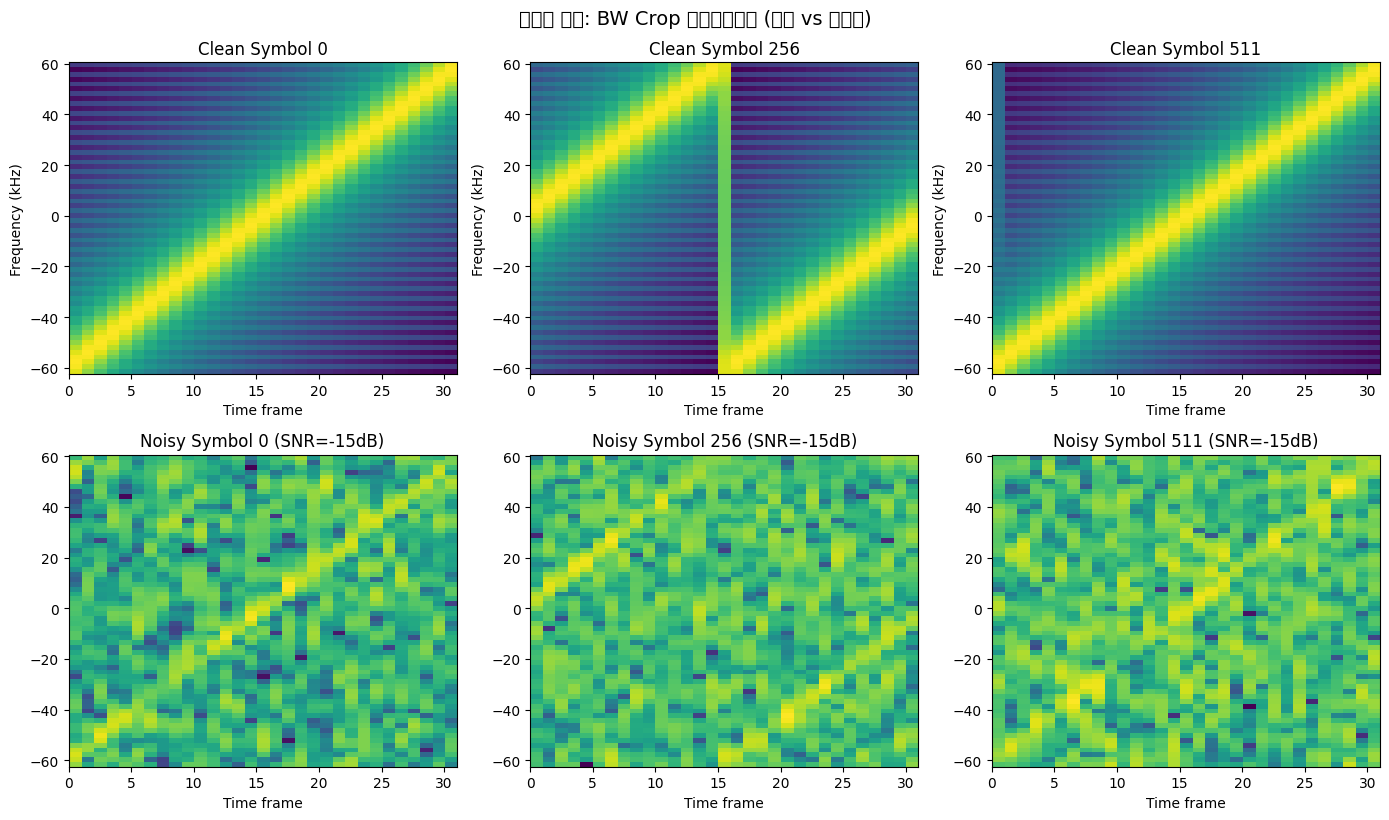


🔍 심볼 추정 검증 (estimate_symbol_custom, 클린 IQ):
   Symbol   0 → Estimated:   0 ✓
   Symbol 100 → Estimated: 100 ✓
   Symbol 256 → Estimated: 256 ✓
   Symbol 400 → Estimated: 400 ✓
   Symbol 511 → Estimated: 511 ✓


In [7]:
# ===== 데이터 검증: BW Crop 스펙트로그램 시각화 =====
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

lora_viz = LoRa(SF, BW, OSF)

# 클린 스펙트로그램 예시 (심볼 0, 256, 511)
for idx, sym in enumerate([0, 256, 511]):
    mag_db, f_crop, _ = stft_bw_crop(clean_iq[sym])
    
    axes[0, idx].imshow(mag_db, aspect='auto', origin='lower', cmap='viridis',
                        extent=[0, mag_db.shape[1], f_crop[0]/1000, f_crop[-1]/1000])
    axes[0, idx].set_title(f'Clean Symbol {sym}')
    axes[0, idx].set_xlabel('Time frame')
    axes[0, idx].set_ylabel('Frequency (kHz)')

# 노이즈 추가 예시 (SNR = -15dB)
for idx, sym in enumerate([0, 256, 511]):
    noisy = lora_viz.awgn_iq(clean_iq[sym], -15)
    mag_db, f_crop, _ = stft_bw_crop(noisy)
    
    axes[1, idx].imshow(mag_db, aspect='auto', origin='lower', cmap='viridis',
                        extent=[0, mag_db.shape[1], f_crop[0]/1000, f_crop[-1]/1000])
    axes[1, idx].set_title(f'Noisy Symbol {sym} (SNR=-15dB)')
    axes[1, idx].set_xlabel('Time frame')

plt.tight_layout()
plt.suptitle('데이터 검증: BW Crop 스펙트로그램 (클린 vs 노이즈)', y=1.02, fontsize=14)
plt.show()

# ⭐ estimate_symbol_custom 사용 (검증된 함수)
print("\n🔍 심볼 추정 검증 (estimate_symbol_custom, 클린 IQ):")
for sym in [0, 100, 256, 400, 511]:
    est, power = estimate_symbol_custom(unit_power(clean_iq[sym]), SF, FS, BW)
    status = "✓" if est == sym else "✗"
    print(f"   Symbol {sym:3d} → Estimated: {est:3d} {status}")

🚀 FEBAM 학습 시작
   구조: 2048 → 4096 → 2048 → 1024 → 512 → 256 → 128 → 64 → 128 → 256 → 512 → 1024 → 2048
   eta=0.0001, 입력 차원=2048
✅ Early stop at step 101
✅ 학습 완료: 625.1초, 101 steps


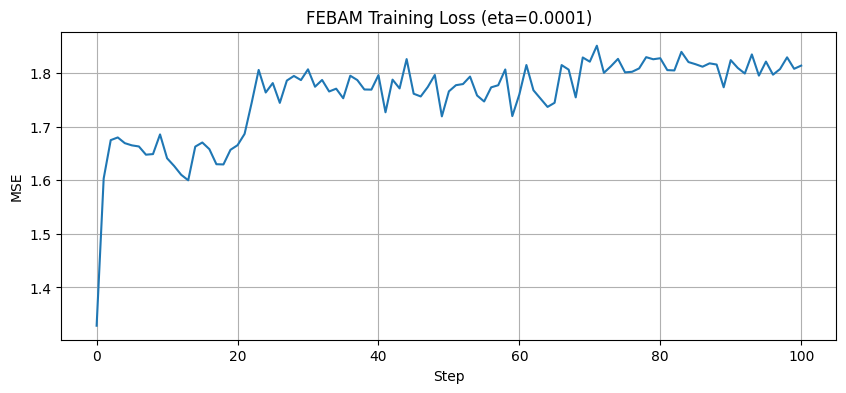

In [8]:
# ===== FEBAM 학습 =====

lora = LoRa(SF, BW, OSF)

# eta 설정 (작은 입력 차원이므로 더 큰 eta 가능)
ETA = 1e-4  # 입력이 2048로 작아졌으므로 더 큰 값 시도 가능

model = make_model(layers, eta=ETA)

def get_clean_batch(batch_size):
    """클린 스펙트로그램 배치 (BW Crop)"""
    idx = np.random.randint(0, len(clean_iq), size=batch_size)
    flat_batch = []
    
    for i in idx:
        mag_db, _, _ = stft_bw_crop(clean_iq[i])
        fvec, _ = flatten_spec(mag_db)
        flat_batch.append(zscore(fvec, global_mean, global_std))
    
    return np.stack(flat_batch).astype(np.float32)

def train_febam(max_steps=TRAIN_MAX_STEPS, batch=TRAIN_BATCH):
    """FEBAM 학습"""
    losses = []
    no_improve = 0
    best = np.inf
    
    for step in range(max_steps):
        xb = get_clean_batch(batch)
        
        # 학습 전 weight 체크
        max_w = max(np.abs(bam.W).max() for bam in model.bams)
        
        try:
            loss = train_step(model, xb)
        except ValueError as e:
            print(f"⚠️ Step {step}: {e}")
            print(f"   Max weight before: {max_w:.4f}")
            break
            
        losses.append(loss)
        
        # 발산 체크
        if np.isnan(loss) or loss > 1e6:
            print(f"⚠️ Step {step}: Loss 발산! loss={loss}")
            break
        
        if loss + EARLY_TOL < best:
            best = loss
            no_improve = 0
        else:
            no_improve += 1
            
        if (step+1) % 200 == 0:
            print(f'Step {step+1:4d}: loss={loss:.6f}, best={best:.6f}, max_W={max_w:.4f}')
            
        if no_improve >= EARLY_PATIENCE:
            print(f'✅ Early stop at step {step+1}')
            break
            
    return losses

print(f"🚀 FEBAM 학습 시작")
print(f"   구조: {' → '.join(str(x) for x in layers)}")
print(f"   eta={ETA}, 입력 차원={input_len}")
t0 = time.time()
loss_history = train_febam()
print(f"✅ 학습 완료: {time.time()-t0:.1f}초, {len(loss_history)} steps")

if len(loss_history) > 0:
    plt.figure(figsize=(10, 4))
    plt.plot(loss_history)
    plt.title(f'FEBAM Training Loss (eta={ETA})')
    plt.xlabel('Step'); plt.ylabel('MSE'); plt.grid(True)
    plt.show()

In [9]:
# ===== eta 값 테스트 (발산 여부 확인) =====
def test_eta_stability(eta_list=[1e-4, 5e-4, 1e-3, 5e-3], test_steps=100):
    """다양한 eta 값으로 학습 안정성 테스트"""
    print("="*60)
    print("📊 eta 안정성 테스트 (FEBAM, 입력 차원 2048)")
    print("="*60)
    
    results = {}
    for eta in eta_list:
        test_model = make_model(layers, eta=eta)
        losses = []
        diverged = False
        
        for step in range(test_steps):
            xb = get_clean_batch(16)  # 작은 배치
            try:
                loss = train_step(test_model, xb)
                if np.isnan(loss) or loss > 1e6:
                    diverged = True
                    break
                losses.append(loss)
            except:
                diverged = True
                break
        
        if diverged:
            status = "❌ 발산"
        else:
            status = f"✅ 안정 (최종 loss: {losses[-1]:.4f})"
        print(f"  eta={eta:.0e}: {status}")
        results[eta] = {'diverged': diverged, 'losses': losses}
    
    print("="*60)
    return results

# 테스트 실행 (선택적)
# eta_results = test_eta_stability()

In [10]:
# ===== 평가: 스펙트로그램에서 직접 심볼 추정 (ISTFT 없음!) =====

def fbeta_score(precision, recall, beta):
    if precision + recall == 0:
        return 0.0
    return (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall)

def eval_spectrogram_direct(num_samples=100, snr_list=None):
    """
    스펙트로그램에서 직접 심볼 추정 (ISTFT 불필요!)
    """
    if snr_list is None:
        snr_list = list(range(0, -31, -5))
    
    results = {snr: {'y_true': [], 'y_pred_before': [], 'y_pred_after': []} for snr in snr_list}
    
    for snr in snr_list:
        for _ in range(num_samples):
            sym = np.random.randint(0, len(clean_iq))
            clean = clean_iq[sym]
            noisy = lora.awgn_iq(clean, snr)
            
            # 노이즈 스펙트로그램에서 추정 (디노이징 전)
            mag_noisy, f_crop, _ = stft_bw_crop(noisy)
            est_before, _ = estimate_from_spectrogram(mag_noisy, f_crop)
            
            # FEBAM 디노이징 후 추정
            mag_denoised, _, f_crop = denoise_spectrogram(noisy, model, global_mean, global_std)
            est_after, _ = estimate_from_spectrogram(mag_denoised, f_crop)
            
            results[snr]['y_true'].append(sym)
            results[snr]['y_pred_before'].append(est_before)
            results[snr]['y_pred_after'].append(est_after)
    
    # 결과 출력
    beta_list = [0.5, 1.0, 2.0, 3.0]
    
    print(f"\n📊 평가: 스펙트로그램 직접 심볼 추정 (ISTFT 없음!)")
    print("="*90)
    print(f"{'SNR':>6} | {'Acc Before':>10} | {'Acc After':>10} | " + 
          " | ".join([f'F{b}' for b in beta_list]))
    print("="*90)
    
    all_metrics = {}
    for snr in snr_list:
        y_true = results[snr]['y_true']
        y_before = results[snr]['y_pred_before']
        y_after = results[snr]['y_pred_after']
        
        acc_before = 100 * np.mean([t == p for t, p in zip(y_true, y_before)])
        acc_after = 100 * np.mean([t == p for t, p in zip(y_true, y_after)])
        
        correct_after = [1 if t == p else 0 for t, p in zip(y_true, y_after)]
        precision = np.mean(correct_after)
        recall = precision
        
        f_scores = [fbeta_score(precision, recall, b) for b in beta_list]
        
        f_str = " | ".join([f'{f*100:5.1f}%' for f in f_scores])
        change = acc_after - acc_before
        change_str = f"({change:+.1f}%)"
        print(f"{snr:>4} dB | {acc_before:>9.1f}% | {acc_after:>9.1f}% {change_str} | {f_str}")
        
        all_metrics[snr] = {
            'acc_before': acc_before, 'acc_after': acc_after,
            'precision': precision, 'recall': recall,
            'f_scores': dict(zip(beta_list, f_scores))
        }
    
    print("="*90)
    return results, all_metrics

# 학습이 완료된 경우에만 평가 실행
if len(loss_history) > 0 and not np.isnan(loss_history[-1]):
    print("📊 평가 시작 (스펙트로그램 직접 추정)...")
    results, metrics = eval_spectrogram_direct(num_samples=50)
else:
    print("⚠️ 학습이 발산했거나 완료되지 않았습니다. 평가를 건너뜁니다.")

📊 평가 시작 (스펙트로그램 직접 추정)...


NameError: name 'estimate_from_spectrogram' is not defined

In [ ]:
# ===== 시각화: 스펙트로그램 디노이징 비교 =====

def visualize_denoising(sym_idx=0, snr=-20):
    """클린/노이즈/디노이징 스펙트로그램 비교"""
    clean = clean_iq[sym_idx]
    noisy = lora.awgn_iq(clean, snr)
    
    # 스펙트로그램 (BW Crop)
    mag_clean, f_crop, _ = stft_bw_crop(clean)
    mag_noisy, _, _ = stft_bw_crop(noisy)
    
    # 디노이징
    mag_denoised, _, _ = denoise_spectrogram(noisy, model, global_mean, global_std)
    
    # 심볼 추정
    est_noisy, _ = estimate_from_spectrogram(mag_noisy, f_crop)
    est_denoised, _ = estimate_from_spectrogram(mag_denoised, f_crop)
    
    # 시각화
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    vmin, vmax = mag_clean.min(), mag_clean.max()
    extent = [0, mag_clean.shape[1], f_crop[0]/1000, f_crop[-1]/1000]
    
    axes[0].imshow(mag_clean, aspect='auto', origin='lower', cmap='viridis', 
                   vmin=vmin, vmax=vmax, extent=extent)
    axes[0].set_title(f'Clean (Symbol={sym_idx})')
    axes[0].set_xlabel('Time frame'); axes[0].set_ylabel('Frequency (kHz)')
    
    axes[1].imshow(mag_noisy, aspect='auto', origin='lower', cmap='viridis', 
                   vmin=vmin, vmax=vmax, extent=extent)
    axes[1].set_title(f'Noisy SNR={snr}dB (Est={est_noisy}) {"✓" if est_noisy==sym_idx else "✗"}')
    axes[1].set_xlabel('Time frame')
    
    im = axes[2].imshow(mag_denoised, aspect='auto', origin='lower', cmap='viridis', 
                        vmin=vmin, vmax=vmax, extent=extent)
    axes[2].set_title(f'FEBAM Denoised (Est={est_denoised}) {"✓" if est_denoised==sym_idx else "✗"}')
    axes[2].set_xlabel('Time frame')
    
    plt.colorbar(im, ax=axes, label='dB', shrink=0.8)
    plt.tight_layout()
    plt.show()
    
    return est_noisy, est_denoised

# 예시 시각화
if len(loss_history) > 0 and not np.isnan(loss_history[-1]):
    print("📈 FEBAM 디노이징 시각화")
    for sym in [0, 128, 256]:
        visualize_denoising(sym_idx=sym, snr=-15)

In [ ]:
# ===== SNR별 성능 그래프 =====

def plot_performance(metrics):
    """SNR별 Accuracy 및 F-score 그래프"""
    snr_list = sorted(metrics.keys(), reverse=True)
    
    acc_before = [metrics[s]['acc_before'] for s in snr_list]
    acc_after = [metrics[s]['acc_after'] for s in snr_list]
    f05 = [metrics[s]['f_scores'][0.5] * 100 for s in snr_list]
    f1 = [metrics[s]['f_scores'][1.0] * 100 for s in snr_list]
    f2 = [metrics[s]['f_scores'][2.0] * 100 for s in snr_list]
    f3 = [metrics[s]['f_scores'][3.0] * 100 for s in snr_list]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy 비교
    axes[0].plot(snr_list, acc_before, 'o--', label='Before FEBAM', linewidth=2, markersize=8)
    axes[0].plot(snr_list, acc_after, 's-', label='After FEBAM', linewidth=2, markersize=8)
    axes[0].set_xlabel('SNR (dB)', fontsize=12)
    axes[0].set_ylabel('Accuracy (%)', fontsize=12)
    axes[0].set_title('Symbol Estimation Accuracy (Spectrogram Direct)', fontsize=14)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim([min(snr_list)-1, max(snr_list)+1])
    axes[0].set_ylim([0, 105])
    
    # F-score 비교
    axes[1].plot(snr_list, f05, 'o-', label='F0.5', linewidth=2, markersize=6)
    axes[1].plot(snr_list, f1, 's-', label='F1.0', linewidth=2, markersize=6)
    axes[1].plot(snr_list, f2, '^-', label='F2.0', linewidth=2, markersize=6)
    axes[1].plot(snr_list, f3, 'd-', label='F3.0', linewidth=2, markersize=6)
    axes[1].set_xlabel('SNR (dB)', fontsize=12)
    axes[1].set_ylabel('F-score (%)', fontsize=12)
    axes[1].set_title('F-scores (After FEBAM Denoising)', fontsize=14)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim([min(snr_list)-1, max(snr_list)+1])
    axes[1].set_ylim([0, 105])
    
    plt.tight_layout()
    plt.show()
    
    # 개선율 출력
    print("\n📊 FEBAM 디노이징 개선율:")
    for snr in snr_list:
        diff = metrics[snr]['acc_after'] - metrics[snr]['acc_before']
        print(f"  SNR {snr:>3}dB: {diff:+.1f}%")

if 'metrics' in dir() and metrics:
    plot_performance(metrics)